# MRI vs MRI+Histo-Aligned: UMAP & Silhouette Comparison (loads .pt artifacts)

This notebook loads **two** MRI encoding datasets (e.g., baseline MRI vs MRI aligned with histopathology), projects both to 2D with UMAP using the same hyperparameters & color palette (if found in your histopath notebook), computes silhouette scores on the **full encodings** and **UMAP-2D** for each, and displays side-by-side UMAP plots.

In [1]:
# --- Paths (EDIT ME) ---
# This notebook expects the artifacts saved by train.py's:
#   save_embeddings(outdir / "val_embeddings",  "val.pt",  embeddings, labels)
#   save_embeddings(outdir / "test_embeddings", "test.pt", embeddings, labels)
#
# Typical layout:
#   <RUN_DIR>/val_embeddings/val.pt
#   <RUN_DIR>/test_embeddings/test.pt

RUN_DIR_A = "/home/ewillis/projects/aip-medilab/ewillis/pca_contrastive/mri_model_medsam_finetune_2D/LATEST/SPIE-RESULTS: results_isup3/baseline"  # e.g., ".../runs/baseline"
RUN_DIR_B = "/home/ewillis/projects/aip-medilab/ewillis/pca_contrastive/mri_model_medsam_finetune_2D/LATEST/SPIE-RESULTS: results_isup3/two_stage"  # e.g., ".../runs/triplet_then_head"

NAME_A = "Baseline"
NAME_B = "Head and Proj"

SET = "test"

PT_A = f"{RUN_DIR_A}/{SET}_embeddings/{SET}.pt"
PT_B = f"{RUN_DIR_B}/{SET}_embeddings/{SET}.pt"

# Optional metadata CSV (only used for sanity-checking row counts).
# Leave as None if you don't have it.
META_A = None  # e.g., f"{RUN_DIR_A}/val_metadata.csv"
META_B = None  # e.g., f"{RUN_DIR_B}/val_metadata.csv"

# --- UMAP hyperparameters ---
UMAP_PARAMS = {
  "n_neighbors": 15,
  "min_dist": 0.1,
  "metric": "cosine",
  "random_state": 42,
  "n_components": 2
}

# --- Color palette ---
# If you have a fixed palette from another notebook, paste it here as a dict like {0:"#...", 1:"#...", ...}
COLORS = None  # will be built based on labels if None


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
try:
    import umap.umap_ as umap
except Exception as e:
    raise RuntimeError("Please install umap-learn: pip install umap-learn")

import torch


/home/ewillis/projects/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def _unpack_pt_payload(payload):
    """Best-effort unpacking for embeddings/labels saved via torch.save()."""
    emb = None
    y = None

    if isinstance(payload, dict):
        # common keys
        for k in ("embeddings", "embedding", "X", "features"):
            if k in payload:
                emb = payload[k]
                break
        for k in ("labels", "label", "y", "targets"):
            if k in payload:
                y = payload[k]
                break
    elif isinstance(payload, (tuple, list)) and len(payload) >= 2:
        emb, y = payload[0], payload[1]
    else:
        raise ValueError(
            f"Don't know how to unpack payload of type {type(payload)}. "
            "Expected a dict with embeddings/labels keys, or a (embeddings, labels) tuple."
        )

    if emb is None or y is None:
        raise ValueError(
            "Could not find both embeddings and labels in the .pt file. "
            "If you changed save_embeddings(), update _unpack_pt_payload() accordingly."
        )

    # to numpy
    if torch.is_tensor(emb):
        emb = emb.detach().cpu().numpy()
    else:
        emb = np.asarray(emb)

    if torch.is_tensor(y):
        y = y.detach().cpu().numpy()
    else:
        y = np.asarray(y)

    return emb, y

def load_encodings_pt(pt_path, meta_path=None):
    """Loads embeddings+labels from a single .pt artifact; meta is optional."""
    payload = torch.load(pt_path, map_location="cpu")
    emb, labels = _unpack_pt_payload(payload)

    meta = None
    if meta_path is not None:
        meta = pd.read_csv(meta_path)
        assert emb.shape[0] == labels.shape[0] == len(meta), (
            "Row count mismatch among embeddings/labels/meta"
        )
    else:
        # lightweight placeholder so downstream code can keep the same shape checks if needed
        meta = pd.DataFrame(index=range(labels.shape[0]))

    return emb, labels, meta

def build_palette(labels, COLORS=None):
    uniq = sorted(pd.unique(labels))
    label_names_6 = {0: 'ISUP_0', 1:'ISUP_1', 2:'ISUP_2', 3:'ISUP_3', 4:'ISUP_4', 5:'ISUP_5'}
    label_names_3 = {0: 'ISUP01', 1:'ISUP23', 2:'ISUP45'}
    label_names = label_names_3 if len(uniq) <= 3 else label_names_6
    if isinstance(COLORS, dict) and len(COLORS) > 0:
        from itertools import cycle
        default_colors = cycle(plt.rcParams['axes.prop_cycle'].by_key().get('color', []))
        palette = {int(k): COLORS.get(int(k), None) for k in uniq}
        for k in uniq:
            if palette[int(k)] is None:
                palette[int(k)] = next(default_colors)
    else:
        from itertools import cycle
        cyc = cycle(plt.rcParams['axes.prop_cycle'].by_key().get('color', []))
        palette = {int(k): next(cyc) for k in uniq}
    return palette, label_names


In [4]:
# --- Load both datasets ---
embA, yA, metaA = load_encodings_pt(PT_A, META_A)
embB, yB, metaB = load_encodings_pt(PT_B, META_B)

print(NAME_A, embA.shape, '|', NAME_B, embB.shape)
assert set(pd.unique(yA)) == set(pd.unique(yB)), "Label sets differ; palette may misalign. Consider remapping."
labels_all = sorted(set(pd.unique(yA)))


Baseline (6762, 512) | Head and Proj (6762, 512)


In [5]:
# --- Build a single palette for both datasets to keep colors consistent ---
palette, label_names = build_palette(np.array(labels_all), COLORS if 'COLORS' in globals() else None)
palette

{0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}

In [6]:
# --- Silhouette on FULL encodings (each dataset standardized separately) ---
scA = StandardScaler(); XA = scA.fit_transform(embA)
scB = StandardScaler(); XB = scB.fit_transform(embB)
silA_euc_full = silhouette_score(XA, yA, metric='euclidean')
silA_cos_full = silhouette_score(XA, yA, metric='cosine')
silB_euc_full = silhouette_score(XB, yB, metric='euclidean')
silB_cos_full = silhouette_score(XB, yB, metric='cosine')
print(NAME_A, f"FULL (cos): {silA_cos_full:.3f} | (euc): {silA_euc_full:.3f}")
print(NAME_B, f"FULL (cos): {silB_cos_full:.3f} | (euc): {silB_euc_full:.3f}")

Baseline FULL (cos): -0.006 | (euc): 0.020
Head and Proj FULL (cos): 0.037 | (euc): 0.251


In [7]:
# --- UMAP to 2D (fit separately for each dataset with identical hyperparameters) ---
reducerA = umap.UMAP(**UMAP_PARAMS)
reducerB = umap.UMAP(**UMAP_PARAMS)
XA2 = reducerA.fit_transform(XA)
XB2 = reducerB.fit_transform(XB)
silA_euc_2d = silhouette_score(XA2, yA, metric='euclidean')
silA_cos_2d = silhouette_score(XA2, yA, metric='cosine')
silB_euc_2d = silhouette_score(XB2, yB, metric='euclidean')
silB_cos_2d = silhouette_score(XB2, yB, metric='cosine')
print(NAME_A, f"UMAP2D (cos): {silA_cos_2d:.3f} | (euc): {silA_euc_2d:.3f}")
print(NAME_B, f"UMAP2D (cos): {silB_cos_2d:.3f} | (euc): {silB_euc_2d:.3f}")

/home/ewillis/projects/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ewillis/projects/aip-medilab/ewillis/pca_contrastive/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Baseline UMAP2D (cos): -0.075 | (euc): -0.195
Head and Proj UMAP2D (cos): -0.123 | (euc): -0.031


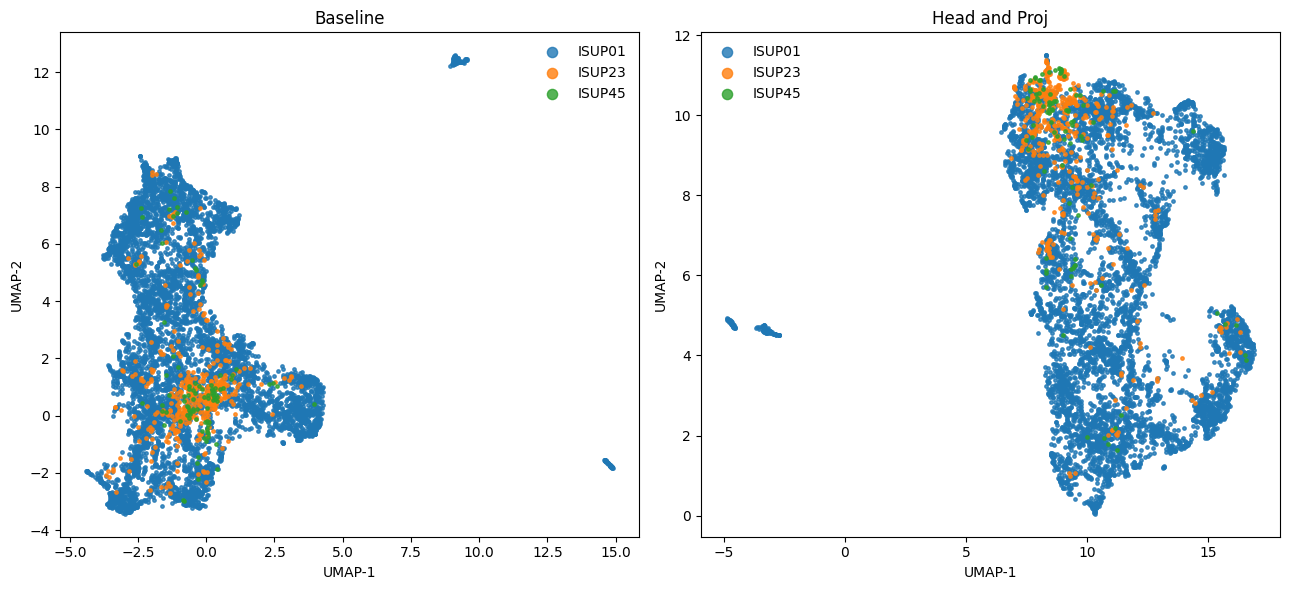

In [8]:
# --- Side-by-side UMAP plots ---
fig, axes = plt.subplots(1, 2, figsize=(13,6), sharex=False, sharey=False)
for ax, X2, y, name in [(axes[0], XA2, yA, NAME_A), (axes[1], XB2, yB, NAME_B)]:
    for k in sorted(pd.unique(y)):
        m = (y == k)
        ax.scatter(X2[m,0], X2[m,1], s=6, alpha=0.8, label=label_names.get(int(k), str(k)), c=palette[int(k)])
    ax.set_title(f"{name}")
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    ax.legend(markerscale=3, frameon=False, loc='best')
plt.tight_layout()
# plt.savefig(f"{ENC_DIR_A}/compare_umap_side_by_side.png", dpi=200)
plt.show()

In [9]:
# --- Summary table ---
summary = pd.DataFrame([
    [NAME_A, 'full', 'cosine',    silA_cos_full],
    [NAME_A, 'full', 'euclidean', silA_euc_full],
    [NAME_A, 'umap2d', 'cosine',    silA_cos_2d],
    [NAME_A, 'umap2d', 'euclidean', silA_euc_2d],
    [NAME_B, 'full', 'cosine',    silB_cos_full],
    [NAME_B, 'full', 'euclidean', silB_euc_full],
    [NAME_B, 'umap2d', 'cosine',    silB_cos_2d],
    [NAME_B, 'umap2d', 'euclidean', silB_euc_2d],
], columns=['dataset','space','metric','silhouette'])
summary_pivot = summary.pivot_table(index='dataset', columns=['space','metric'], values='silhouette')
display(summary_pivot)
# summary.to_csv(f"{ENC_DIR_A}/compare_umap_silhouette_raw.csv", index=False)
# summary_pivot.to_csv(f"{ENC_DIR_A}/compare_umap_silhouette_wide.csv")


space              full              umap2d          
metric           cosine euclidean    cosine euclidean
dataset                                              
Baseline      -0.006330  0.020188 -0.074557 -0.194915
Head and Proj  0.036604  0.251060 -0.122637 -0.030788